# Classifying Network Traffic Flow
This model will accurately classify network traffic into normal and different types of attack categories based on various network flow features.
- dataset: DDos.pcap_ISCX.csv

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from tensorflow.keras import layers, models
import tensorflow as tf
import cloudpickle
import warnings
import dill
import os

# settings
SESSION_FILE = "variables.session"
def save_session():
    dill.dump_session(SESSION_FILE)
    print(f"Session saved to {SESSION_FILE}")
def load_session():
    if os.path.exists(SESSION_FILE):
        dill.load_session(SESSION_FILE)
        print(f"Session loaded from {SESSION_FILE}")
    else:
        print("No saved session found.")
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",10)

In [2]:
# load everything
load_session()

No saved session found.


In [3]:
# load dataset
data = pd.read_csv("DDos.pcap_ISCX.csv")
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# data backup
df = data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

# Data Preprocessing

In [5]:
# duplicates
df.drop_duplicates(inplace= True)
print(f'no of rows reduced to {df.shape[0]}')

no of rows reduced to 223112


In [6]:
# null values
df.dropna(inplace= True)
print(f'no of rows reduced to {df.shape[0]}')

no of rows reduced to 223108


In [7]:
# outliers
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,223108.000000,2.231080e+05,223108.000000,223108.000000,223108.000000,2.231080e+05,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,223108.000000,223108.0,223108.0,223108.0,223108.000000,223108.000000,2.231080e+05,2.231080e+05,223108.000000,223108.000000,223108.000000,223108.000000,2.231080e+05,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.0,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.000000,223108.0,223108.0,223108.0,223108.0,223108.0,223108.0,223108.000000,223108.000000,223108.000000,2.231080e+05,223108.000000,223108.000000,223108.000000,223108.000000,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05,2.231080e+05
mean,8982.290299,1.643352e+07,4.905431,4.611632,949.680406,6.029469e+03,544.585766,27.902227,166.462549,217.443394,2767.181513,16.179859,900.325900,1244.712798,inf,inf,1.599231e+06,4.298734e+06,1.364912e+07,2.844196e+04,1.557841e+07,2.570609e+06,5.256561e+06,1.314783e+07,2.098205e+05,6.642292e+06,9.588324e+05,1.629339e+06,4.621499e+06,2.284501e+05,0.033441,0.0,0.0,0.0,112.144988,107.642182,1.132407e+04,1.580816e+03,7.863766,3263.367020,520.581686,1098.147663,2.822861e+06,0.001614,0.033441,0.000121,0.355312,0.507750,0.142102,0.0,0.000121,1.009888,580.718033,166.462549,900.325900,112.144988,0.0,0.0,0.0,0.0,0.0,0.0,4.905431,949.680406,4.611632,6.029469e+03,4274.672307,607.794526,3.336048,21.434677,1.870106e+05,1.308723e+04,2.105443e+05,1.797194e+05,1.044407e+07,3.654634e+06,1.303027e+07,7.846948e+06
std,19847.377786,3.166039e+07,15.509886,21.880349,3267.107818,3.944426e+04,1874.273698,164.244269,507.628839,801.766334,3715.465181,50.028138,1123.258102,1738.215775,NaN,NaN,2.712022e+06,7.653661e+06,2.681855e+07,7.642807e+05,3.174993e+07,5.963201e+06,1.083504e+07,2.761416e+07,3.817523e+06,2.210243e+07,4.612235e+06,5.505227e+06,1.626631e+07,4.042897e+06,0.179786,0.0,0.0,0.0,377.917142,514.711688,1.049791e+05,1.997173e+04,15.589758,3820.020167,559.969975,1271.740430,4.128949e+06,0.040137,0.179786,0.011000,0.478609,0.499941,0.349155,0.0,0.011000,1.437707,627.190061,507.628839,1123.258102,377.917142,0.0,0.0,0.0,0.0,0.0,0.0,15.509886,3267.107818,21.880349,3.944426e+04,8024.599000,4342.508293,12.338559,4.098817,8.023722e+05,2.115079e+05,9.052535e+05,7.886422e+05,2.195281e+07,1.282598e+07,2.704327e+07,1.992992e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.00

In [8]:
# dropping irrelevant data
df = df[df['Flow Bytes/s'] != df['Flow Bytes/s'].min()]
df = df[df['Flow Bytes/s'] != df['Flow Bytes/s'].max()]
print(f'no of rows reduced to {df.shape[0]}')

no of rows reduced to 223080


In [9]:
# save data
file_name = "DDos.pcap_ISCX_cleaned.csv"
df.to_csv(file_name, index= False)
print(f"data saved as {file_name}")

data saved as DDos.pcap_ISCX_cleaned.csv


In [10]:
# numeric and non numeric columns
non_numeric_columns = df.select_dtypes(include= ['object']).columns.to_list()
numeric_columns = df.select_dtypes(exclude= ['object']).columns.to_list()
print(f'non numeric columns: {non_numeric_columns}')
print(f'numeric columns: {numeric_columns}')

# # data encoding
label = LabelEncoder()
for i in non_numeric_columns:
    df[i] = label.fit_transform(df[i])
    print(f'\n{i}:')
    for j, encoded in zip(label.classes_, range(len(label.classes_))):
        print(f'{j}: {encoded}')
df.head()

non numeric columns: [' Label']
numeric columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [11]:
# setting feature and target
x = df.drop(columns= ' Label')
y = df[' Label']
non_numeric_columns.remove(' Label')
features = x.columns.to_list()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_columns),
    ('cat', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False), non_numeric_columns)
])

# split dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

# data preprocessing
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.fit_transform(x_test)

# Deep Learning Model development

In [12]:
# build DL model
dl = models.Sequential([
    layers.Input(shape=(x_train.shape[1], 1)),
    layers.Flatten(),
    layers.Dense(128, activation= 'relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation= 'softmax'),
    layers.Dropout(0.2),
    layers.Dense(2, activation= 'sigmoid')
])

# compile model
dl.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# model configuration
dl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,498 (72.26 KB)

 Trainable params: 18,498 (72.26 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# train model
dl.fit(x_train, y_train, epochs= 5)
test_loss, test_accuracy = dl.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Epoch 1/5
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9239 - loss: 0.2222
Epoch 2/5
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9823 - loss: 0.0615
Epoch 3/5
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9942 - loss: 0.0328
Epoch 4/5
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9940 - loss: 0.0271
Epoch 5/5
5577/5577 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9966 - loss: 0.0170
1395/1395 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9991 - loss: 0.0049
Test Loss: 0.0048
Test Accuracy: 0.9992


In [14]:
# prediction
y_predict_probability = dl.predict(x_test)
y_predict = np.argmax(y_predict_probability, axis= 1)

# model evaluation
accuracy = accuracy_score(y_test, y_predict)
precision = round(precision_score(y_test, y_predict), 4)
recall = round(recall_score(y_test, y_predict), 4)
f1 = round(f1_score(y_test, y_predict), 4)
conf = confusion_matrix(y_test, y_predict)
report = classification_report(y_test, y_predict)

print(f'accuracy score: {accuracy:.4f}')
print('\nconfusion matrix:\n',conf)
print('\nclassification report:\n',report)

1395/1395 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
accuracy score: 0.9992

confusion matrix:
 [[18929     6]
 [   31 25650]]

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18935
           1       1.00      1.00      1.00     25681

    accuracy                           1.00     44616
   macro avg       1.00      1.00      1.00     44616
weighted avg       1.00      1.00      1.00     44616



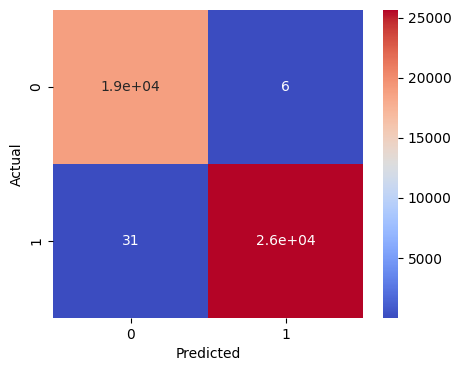

True Values: 44579
Fake Values: 37


In [15]:
# visualizing confusion matrix
plt.figure(figsize= (5,4))
sns.heatmap(conf, annot= True, cmap= 'coolwarm', xticklabels= y.unique(), yticklabels= y.unique())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(f'True Values: {conf[0][0] + conf[1][1]}')
print(f'Fake Values: {conf[1][0] + conf[0][1]}')

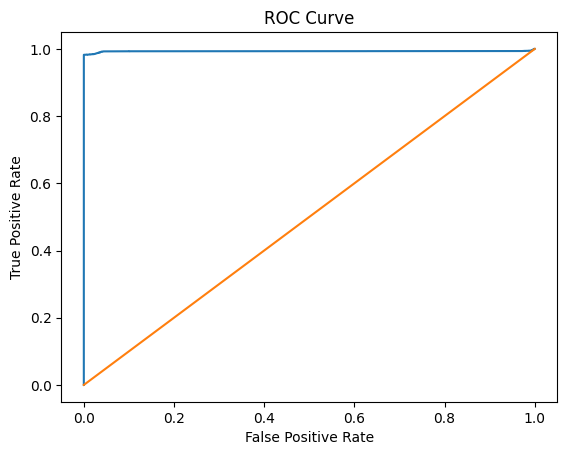

AUC Score: 0.993


In [16]:
# Predict probabilities
y_predict_probability = np.max(y_predict_probability, axis= 1)

# ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_predict_probability)
auc_score = round(auc(fpr, tpr), 4)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print("AUC Score:", auc_score)

In [17]:
# storing dl model performance
eval_df = {
    'model': [dl],
    'model type': ['DL'],
    'accuracy': [accuracy],
    'precision': [precision],
    'recall': [recall],
    'f1-score': [f1],
    'AUC Score': [auc_score]
}
print("data stored in eval_df successfully")

data stored in eval_df successfully


In [18]:
# overfitting and underfitting check
y_predict = np.argmax(dl.predict(x_train), axis= 1)

# model evaluation
accuracy = round(accuracy_score(y_train, y_predict), 4)
conf = confusion_matrix(y_train, y_predict)
report = classification_report(y_train, y_predict)

print('accuracy score: ',accuracy)
print('\nconfusion matrix:\n',conf)
print('\nclassification report:\n',report)

5577/5577 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
accuracy score:  0.9989

confusion matrix:
 [[ 76101     30]
 [   175 102158]]

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     76131
           1       1.00      1.00      1.00    102333

    accuracy                           1.00    178464
   macro avg       1.00      1.00      1.00    178464
weighted avg       1.00      1.00      1.00    178464



# Machine Learning Model Development

In [19]:
# model details
model_dict = {
    'random forest': RandomForestClassifier(random_state= 42),
    'AdaBoost': AdaBoostClassifier(algorithm= 'SAMME', random_state= 42),
    'XGBoost': XGBClassifier(use_label_encoder= False, eval_matrics= 'logloss'),
    'lightgbm': LGBMClassifier(),
    'catboost': CatBoostClassifier()
}

# hyperparameter details
search_space = {
    'iterations': [500],
    'max_iter': [1000],
    'n_estimator': [100],
    'max_depth': [None, 15],
    'border_count': [64],
    'num_leaves': [31, 50],
    'l2_leaf_reg': [3],
    'depth': [6],
    'learning_rate': [0.05, 0.1],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'max_leaf_nodes': [None],
    'boosting_type': ['gbdt'],
}
catboost_search_space = {
    'learning_rate': [0.08, 0.1],
    'iterations': [500],
    'depth': [4, 6]
}

# filter hyperparameter
def filter_hyperparameter(model, space):
    if isinstance(model, CatBoostClassifier):
        return catboost_search_space
    valid_key = model.get_params()
    param_grid = {k:v for k,v in space.items() if k in valid_key}
    return param_grid

In [20]:
# model training with grid search
result = []
i = 0
for name, model in model_dict.items():
    print(f'Tuning for {name}')
    param_grid = filter_hyperparameter(model, search_space)
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='weighted'),
        'recall': make_scorer(recall_score, average='weighted'),
        'f1': make_scorer(f1_score, average='weighted'),
    }
    grid = GridSearchCV(estimator= model, param_grid= param_grid, cv= 2, scoring= scoring, refit= 'accuracy', n_jobs= -1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_predict = best_model.predict(x_test)
    report = classification_report(y_test, y_predict, output_dict= True)
    conf = confusion_matrix(y_test, y_predict)
    result.append({
        'model_name': name,
        'best_parameter': grid.best_params_,
        'accuracy': round(accuracy_score(y_test, y_predict), 4),
        'F1_score': round(report['weighted avg']['f1-score'], 4),
        'precision': round(report['weighted avg']['precision'], 4),
        'recall': round(report['weighted avg']['recall'], 4),
    })
    i+=1
print('model tuning completed')

Tuning for random forest
Tuning for AdaBoost
Tuning for XGBoost
Tuning for lightgbm
[LightGBM] [Info] Number of positive: 102333, number of negative: 76131
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077994 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14231
[LightGBM] [Info] Number of data points in the train set: 178464, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.573410 -> initscore=0.295777
[LightGBM] [Info] Start training from score 0.295777
Tuning for catboost
0:	learn: 0.4319799	total: 233ms	remaining: 1m 56s
1:	learn: 0.2529515	total: 323ms	remaining: 1m 20s
2:	learn: 0.1514631	total: 418ms	remaining: 1m 9s
3:	learn: 0.0924136	total: 520ms	remaining: 1m 4s
4:	learn: 0.0566199	total: 650ms	remaining: 1m 4s
5:	learn: 0.0378973	total: 790ms	remaining: 1m 5s
6:	learn: 0.0265050	total: 939ms	remaining: 1m 6s
7:	learn: 0.0180115	total: 1.07s	remaining: 1m 5s

In [21]:
# finding best model
model_df = pd.DataFrame(result)
model_df.sort_values(by= 'accuracy', ascending= False, inplace= True)
best_model = model_df.iloc[0]['model_name']
best_parameter = model_df.iloc[0]['best_parameter']
print("best model is:", best_model)
print("best parameter is:", best_parameter)
model_df

best model is: AdaBoost
best parameter is: {'learning_rate': 0.1}


,model_name,best_parameter,accuracy,F1_score,precision,recall
1,AdaBoost,{'learning_rate': 0.1},0.9946,0.9946,0.9946,0.9946
0,random forest,"{'max_depth': 15, 'max_leaf_nodes': None, 'min...",0.9828,0.9828,0.9835,0.9828
4,catboost,"{'depth': 6, 'iterations': 500, 'learning_rate...",0.8314,0.8309,0.8794,0.8314
3,lightgbm,"{'boosting_type': 'gbdt', 'learning_rate': 0.0...",0.7884,0.7857,0.8588,0.7884
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': None}",0.4250,0.2542,0.7345,0.4250


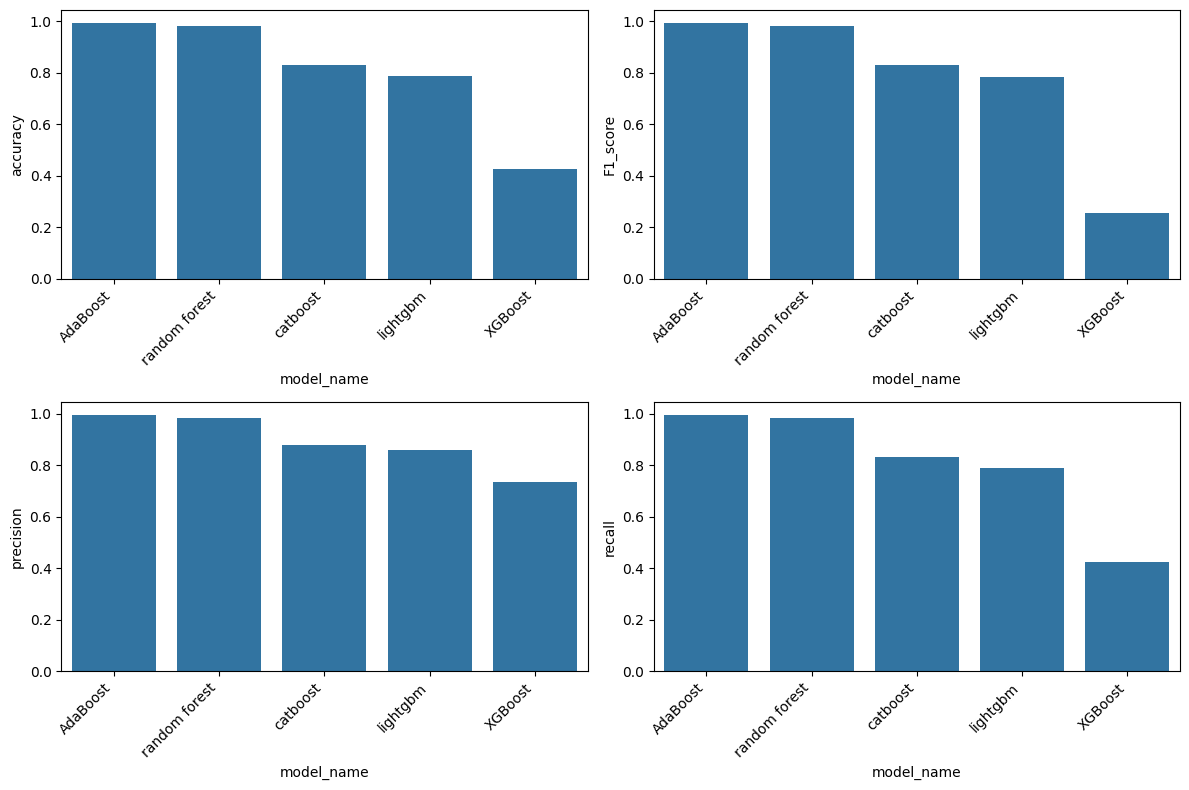

In [22]:
# ploting the netrics
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# accuracy
sns.barplot(x='model_name', y='accuracy', data=model_df, ax=ax[0][0])
ax[0][0].set_xticklabels(ax[0][0].get_xticklabels(), rotation=45, ha='right')

# F1-Score
sns.barplot(x='model_name', y='F1_score', data=model_df, ax=ax[0][1])
ax[0][1].set_xticklabels(ax[0][1].get_xticklabels(), rotation=45, ha='right')

# Precision
sns.barplot(x='model_name', y='precision', data=model_df, ax=ax[1][0])
ax[1][0].set_xticklabels(ax[1][0].get_xticklabels(), rotation=45, ha='right')

# Recall
sns.barplot(x='model_name', y='recall', data=model_df, ax=ax[1][1])
ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

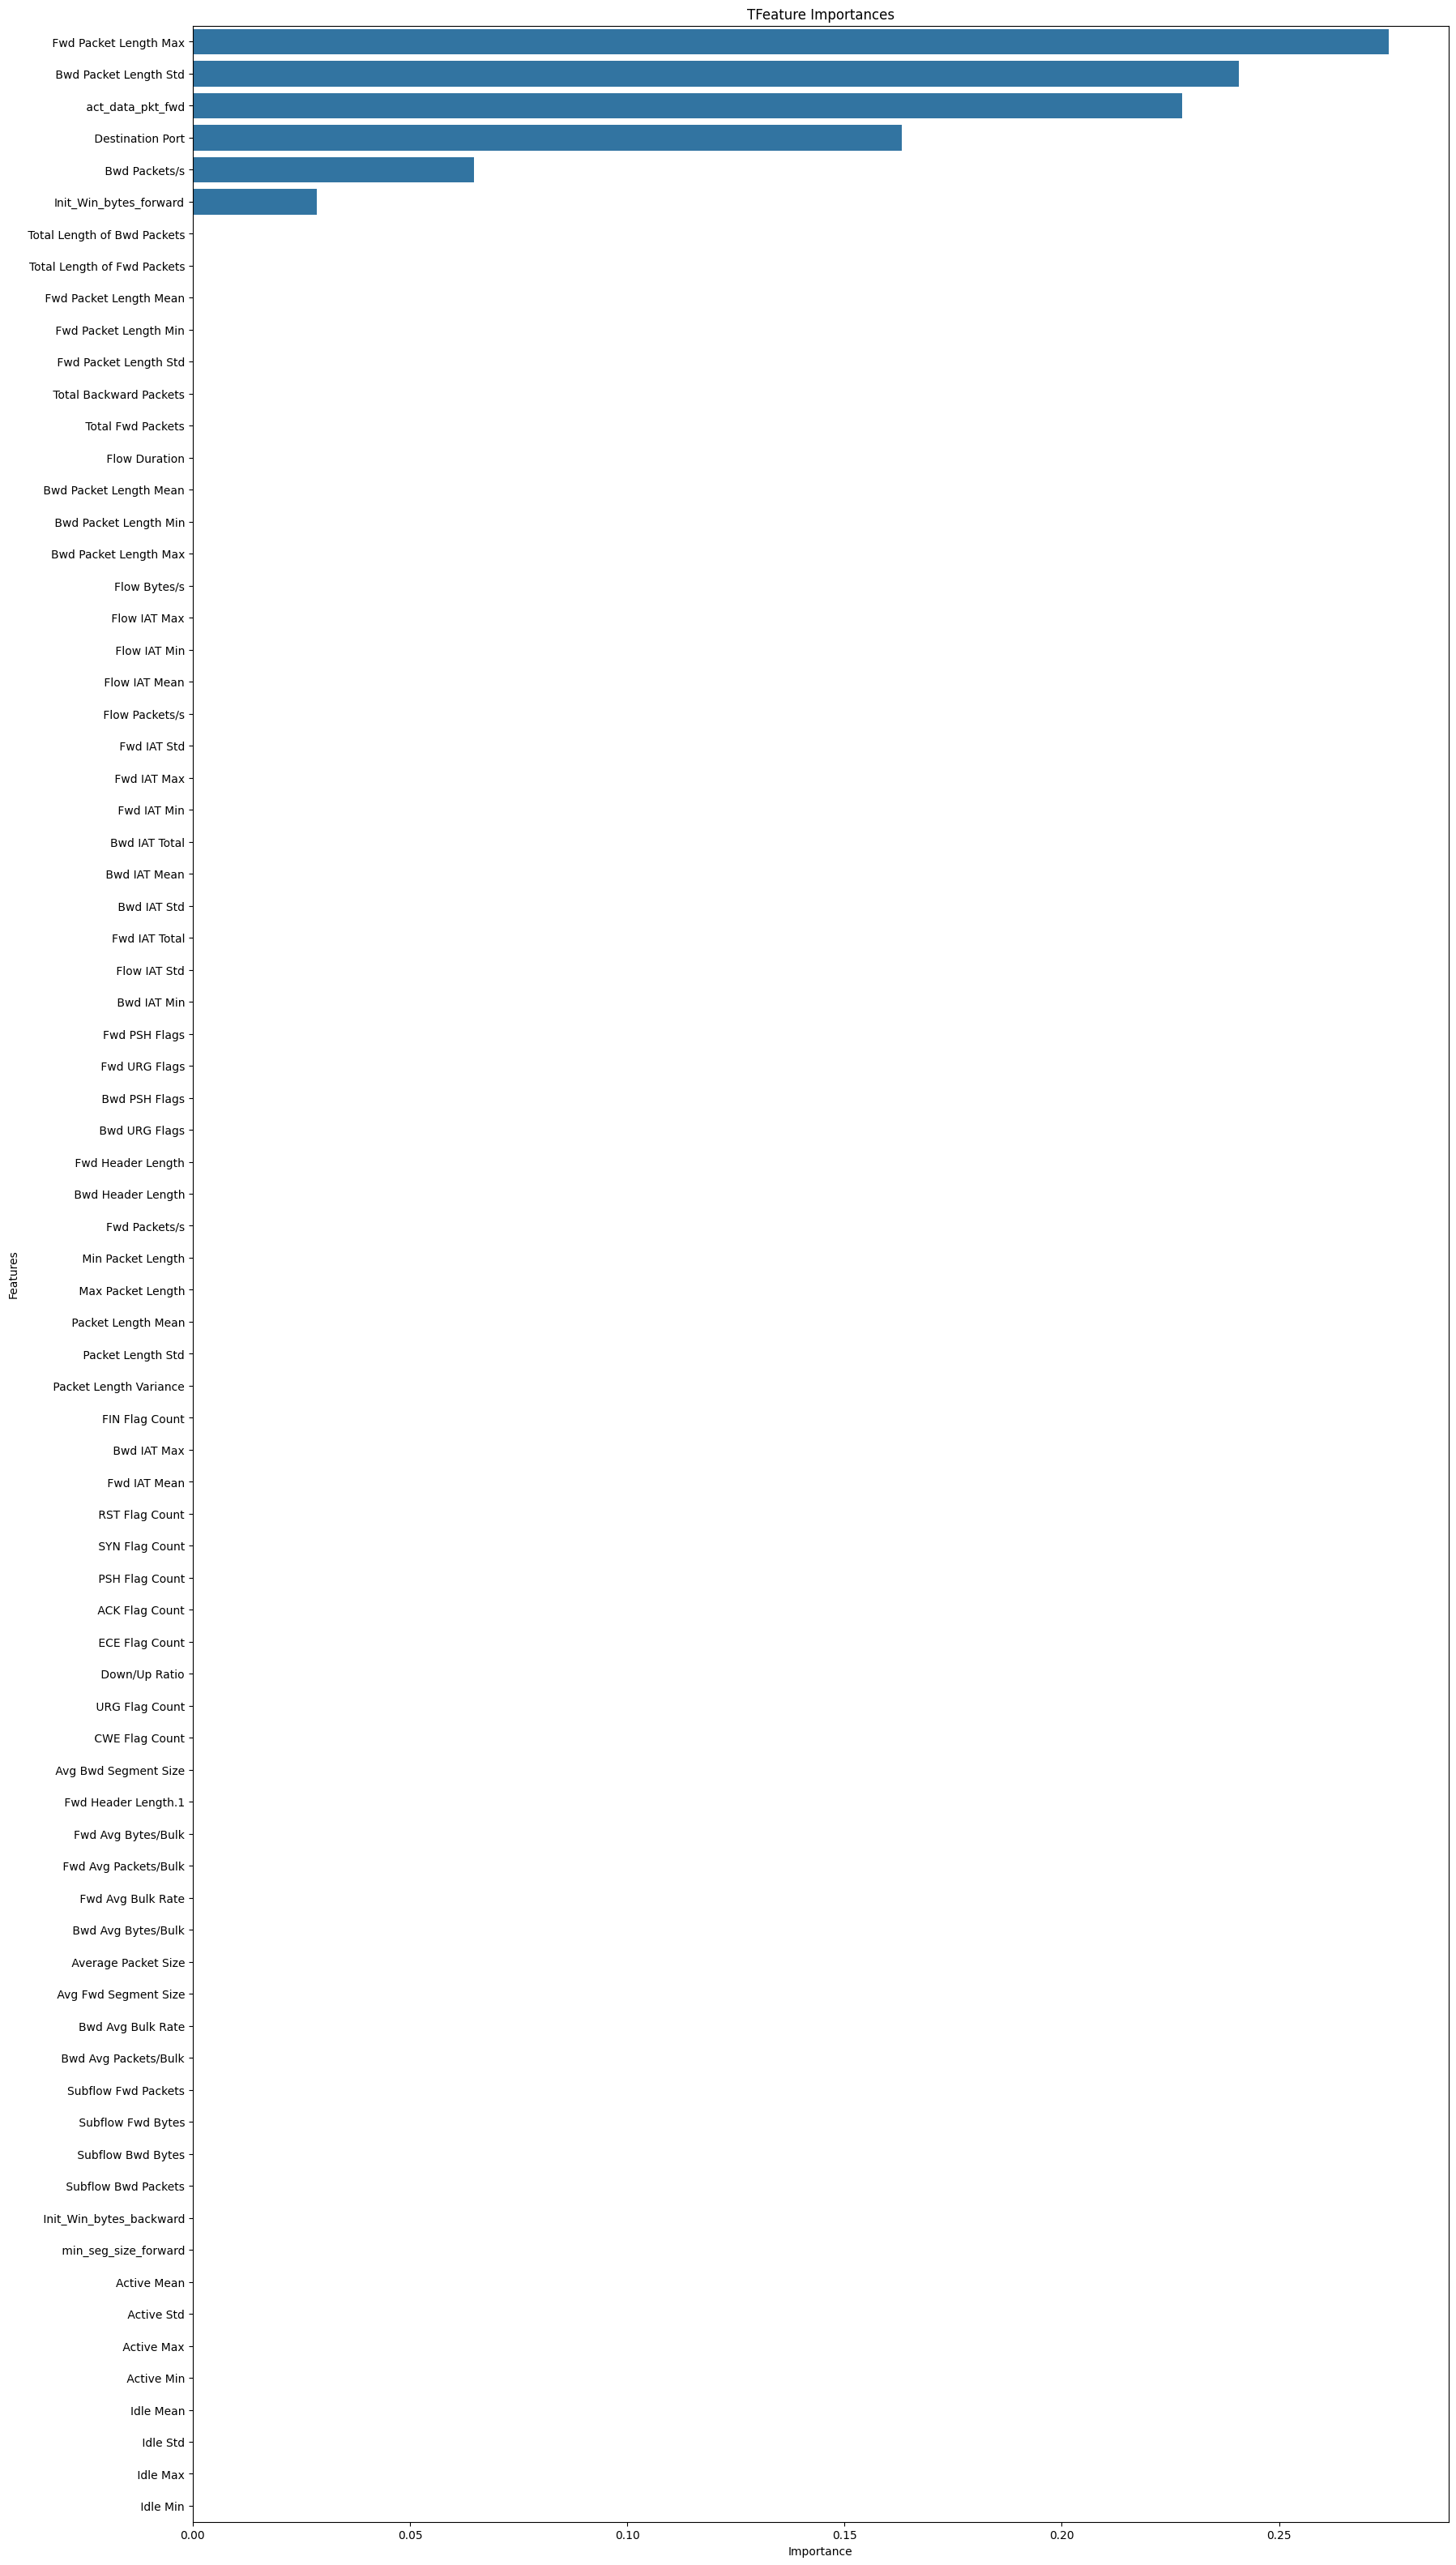

In [ ]:
# best ml model
ml = model_dict[best_model].set_params(**best_parameter)

# best ml model training and testing
ml.fit(x_train, y_train)

# Feature importance
importances = ml.feature_importances_
feature_importances = pd.DataFrame({'Features': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
feature_importances

# Plotting Feature Importance
plt.figure(figsize=(20, 40))
sns.barplot(x='Importance', y='Features', data=feature_importances)
plt.title('Feature Importances')
plt.show()

In [24]:
# feature selection for ML model
top_features = feature_importances[feature_importances['Importance'] > 0.01]['Features'].tolist()
df_ml = df[top_features + [' Label']]

# split dataset
x = df_ml.drop(columns= ' Label')
y = df_ml[' Label']

# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

# ML Preprocessing pipeline
ml_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), top_features)
])

# data preprocessing
x_train = ml_preprocessor.fit_transform(x_train)
x_test = ml_preprocessor.fit_transform(x_test)

In [25]:
# model training and testing
ml.fit(x_train, y_train)
y_predict = ml.predict(x_test)
y_predict_probability = ml.predict_proba(x_test)

# model evaluation
accuracy = round(accuracy_score(y_test, y_predict), 4)
precision = round(precision_score(y_test, y_predict), 4)
recall = round(recall_score(y_test, y_predict), 4)
f1 = round(f1_score(y_test, y_predict), 4)
conf = confusion_matrix(y_test, y_predict)
report = classification_report(y_test, y_predict)

print('best model: ',best_model)
print('accuracy score: ',accuracy)
print('\nconfusion matrix:\n',conf)
print('\nclassification report:\n',report)

best model:  AdaBoost
accuracy score:  0.9946

confusion matrix:
 [[18715   220]
 [   21 25660]]

classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     18935
           1       0.99      1.00      1.00     25681

    accuracy                           0.99     44616
   macro avg       1.00      0.99      0.99     44616
weighted avg       0.99      0.99      0.99     44616



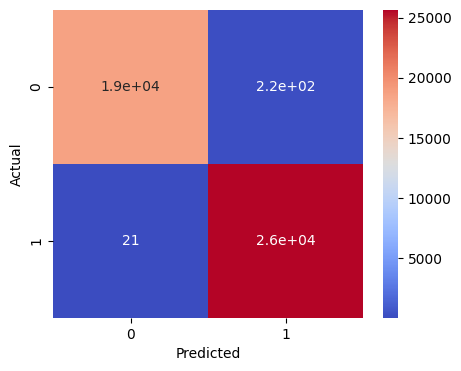

True Values: 44375
Fake Values: 241


In [26]:
# visualizing confusion matrix
plt.figure(figsize= (5,4))
sns.heatmap(conf, annot= True, cmap= 'coolwarm', xticklabels= y.unique(), yticklabels= y.unique())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(f'True Values: {conf[0][0] + conf[1][1]}')
print(f'Fake Values: {conf[1][0] + conf[0][1]}')

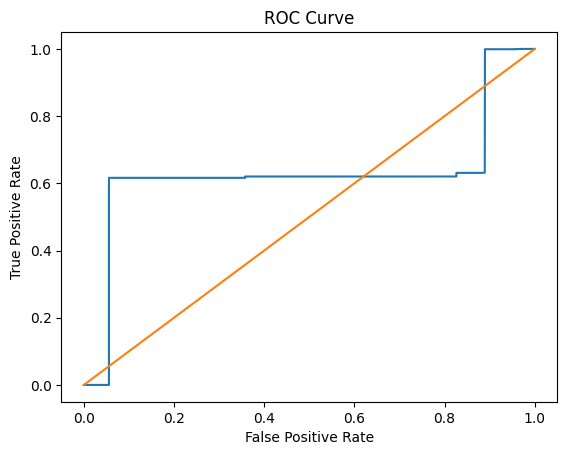

AUC Score: 0.6272


In [27]:
# Predict probabilities
y_predict_probability = np.max(y_predict_probability, axis= 1)

# ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_predict_probability)
auc_score = round(auc(fpr, tpr), 4)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print("AUC Score:", auc_score)

In [28]:
# storing ml model performance
eval_df['model'].append(ml)
eval_df['model type'].append('ML')
eval_df['accuracy'].append(accuracy)
eval_df['precision'].append(precision)
eval_df['recall'].append(recall)
eval_df['f1-score'].append(f1)
eval_df['AUC Score'].append(auc_score)
print("data stored in eval_df successfully")

data stored in eval_df successfully


In [29]:
# overfitting and underfitting check
y_predict = ml.predict(x_train)

# model evaluation
accuracy = round(accuracy_score(y_train, y_predict), 4)
conf = confusion_matrix(y_train, y_predict)
report = classification_report(y_train, y_predict)

print('accuracy score: ',accuracy)
print('\nconfusion matrix:\n',conf)
print('\nclassification report:\n',report)

accuracy score:  0.9854

confusion matrix:
 [[ 73599   2532]
 [    70 102263]]

classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     76131
           1       0.98      1.00      0.99    102333

    accuracy                           0.99    178464
   macro avg       0.99      0.98      0.99    178464
weighted avg       0.99      0.99      0.99    178464



# Model Comparison and data pipeline

In [30]:
# evaluation result
eval_df = pd.DataFrame(eval_df)
eval_df

,model,model type,accuracy,precision,recall,f1-score,AUC Score
0,"<Sequential name=sequential, built=True>",DL,0.999171,0.9998,0.9988,0.9993,0.9930
1,"(DecisionTreeClassifier(max_depth=1, random_st...",ML,0.994600,0.9915,0.9992,0.9953,0.6272


<Axes: xlabel='Metric', ylabel='Score'>

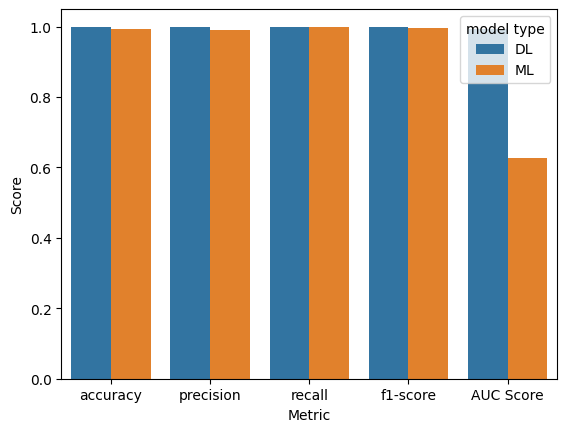

In [31]:
# model evaluation chart
sns.barplot(
    data=eval_df.drop(columns= 'model').melt(id_vars= 'model type', var_name= 'Metric', value_name= 'Score'),
    x='Metric',
    y='Score',
    hue='model type'
)

In [ ]:
# retrain best model
"""
Both the models performed well. But the ML model didn't performed well in AUC score. So, the DL model is being retrained with all the data.
"""
x = df.drop(columns= ' Label')
y = df[' Label']
x = preprocessor.fit_transform(x)
dl.fit(x, y, epochs= 5)

# pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# save model
model_name = "model.pkl"
with open(model_name, 'wb') as f:
    cloudpickle.dump(pipeline, f)
print(f'model saved as {model_name}')

Epoch 1/5
6972/6972 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9980 - loss: 0.0120
Epoch 2/5
6972/6972 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9983 - loss: 0.0100
Epoch 3/5
6972/6972 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9985 - loss: 0.0084
Epoch 4/5
6972/6972 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9986 - loss: 0.0075
Epoch 5/5
6972/6972 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9987 - loss: 0.0064
model saved as model.pkl


In [33]:
# save everything
save_session()

Session saved to variables.session
